# Data Science Project

## Question
- Predicting Hepatitis Mortality Rate with ML

## Workflow
- Data Prep
- EDA
- Feature Selection
- Interpret Model
- Serialization
- Production with Streamlit or Flask

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [17]:
df = pd.read_csv("data/hepatitis.data")
df.head()

,2,30,2.1,1,2.2,2.3,2.4,2.5,1.1,2.6,2.7,2.8,2.9,2.10,1.00,85,18,4.0,?,1.2
0,2,50,1,1,2,1,2,2,1,2,2,2,2,2,0.90,135,42,3.5,?,1
1,2,78,1,2,2,1,2,2,2,2,2,2,2,2,0.70,96,32,4.0,?,1
2,2,31,1,?,1,2,2,2,2,2,2,2,2,2,0.70,46,52,4.0,80,1
3,2,34,1,2,2,2,2,2,2,2,2,2,2,2,1.00,?,200,4.0,?,1
4,2,34,1,2,2,2,2,2,2,2,2,2,2,2,0.90,95,28,4.0,75,1


In [18]:
col_names = ["Class", "AGE", "SEX", "STEROID", "ANTIVIRALS","FATIGUE", "MALAISE", "ANOREXIA", "LIVER BIG", "LIVER FIRM", "SPLEEN PALPABLE", "SPIDERS", "ASCITES", "VARICES", "BILIRUBIN",  "ALK PHOSPHATE", "SGOT", "ALBUMIN","PROTIME", "HISTOLOGY"]
    
col_names

['Class',
 'AGE',
 'SEX',
 'STEROID',
 'ANTIVIRALS',
 'FATIGUE',
 'MALAISE',
 'ANOREXIA',
 'LIVER BIG',
 'LIVER FIRM',
 'SPLEEN PALPABLE',
 'SPIDERS',
 'ASCITES',
 'VARICES',
 'BILIRUBIN',
 'ALK PHOSPHATE',
 'SGOT',
 'ALBUMIN',
 'PROTIME',
 'HISTOLOGY']

In [19]:
df = pd.read_csv("data/hepatitis.data", names = col_names)
df.head()

,Class,AGE,SEX,STEROID,ANTIVIRALS,FATIGUE,MALAISE,ANOREXIA,LIVER BIG,LIVER FIRM,SPLEEN PALPABLE,SPIDERS,ASCITES,VARICES,BILIRUBIN,ALK PHOSPHATE,SGOT,ALBUMIN,PROTIME,HISTOLOGY
0,2,30,2,1,2,2,2,2,1,2,2,2,2,2,1.00,85,18,4.0,?,1
1,2,50,1,1,2,1,2,2,1,2,2,2,2,2,0.90,135,42,3.5,?,1
2,2,78,1,2,2,1,2,2,2,2,2,2,2,2,0.70,96,32,4.0,?,1
3,2,31,1,?,1,2,2,2,2,2,2,2,2,2,0.70,46,52,4.0,80,1
4,2,34,1,2,2,2,2,2,2,2,2,2,2,2,1.00,?,200,4.0,?,1


In [24]:
#Cleaning Columns names
df.columns

Index(['Class', 'AGE', 'SEX', 'STEROID', 'ANTIVIRALS', 'FATIGUE', 'MALAISE',
       'ANOREXIA', 'LIVER BIG', 'LIVER FIRM', 'SPLEEN PALPABLE', 'SPIDERS',
       'ASCITES', 'VARICES', 'BILIRUBIN', 'ALK PHOSPHATE', 'SGOT', 'ALBUMIN',
       'PROTIME', 'HISTOLOGY'],
      dtype='object')

In [26]:
#Converting to lowercase
df.columns.str.lower().str.replace(' ', ' _ ')



Index(['class', 'age', 'sex', 'steroid', 'antivirals', 'fatigue', 'malaise',
       'anorexia', 'liver _ big', 'liver _ firm', 'spleen _ palpable',
       'spiders', 'ascites', 'varices', 'bilirubin', 'alk _ phosphate', 'sgot',
       'albumin', 'protime', 'histology'],
      dtype='object')

In [28]:
df.columns = df.columns.str.lower().str.replace(' ', ' _ ')

In [30]:
df.head()

,class,age,sex,steroid,antivirals,fatigue,malaise,anorexia,liver _ big,liver _ firm,spleen _ palpable,spiders,ascites,varices,bilirubin,alk _ phosphate,sgot,albumin,protime,histology
0,2,30,2,1,2,2,2,2,1,2,2,2,2,2,1.00,85,18,4.0,?,1
1,2,50,1,1,2,1,2,2,1,2,2,2,2,2,0.90,135,42,3.5,?,1
2,2,78,1,2,2,1,2,2,2,2,2,2,2,2,0.70,96,32,4.0,?,1
3,2,31,1,?,1,2,2,2,2,2,2,2,2,2,0.70,46,52,4.0,80,1
4,2,34,1,2,2,2,2,2,2,2,2,2,2,2,1.00,?,200,4.0,?,1


In [32]:
df.dtypes

class                 int64
age                   int64
sex                   int64
steroid              object
antivirals            int64
fatigue              object
malaise              object
anorexia             object
liver _ big          object
liver _ firm         object
spleen _ palpable    object
spiders              object
ascites              object
varices              object
bilirubin            object
alk _ phosphate      object
sgot                 object
albumin              object
protime              object
histology             int64
dtype: object

In [34]:
#Replacing missing valuse

df.replace('?', np.nan, inplace=True)
df


,class,age,sex,steroid,antivirals,fatigue,malaise,anorexia,liver _ big,liver _ firm,spleen _ palpable,spiders,ascites,varices,bilirubin,alk _ phosphate,sgot,albumin,protime,histology
0,2,30,2,1,2,2,2,2,1,2,2,2,2,2,1.00,85,18,4.0,NaN,1
1,2,50,1,1,2,1,2,2,1,2,2,2,2,2,0.90,135,42,3.5,NaN,1
2,2,78,1,2,2,1,2,2,2,2,2,2,2,2,0.70,96,32,4.0,NaN,1
3,2,31,1,NaN,1,2,2,2,2,2,2,2,2,2,0.70,46,52,4.0,80,1
4,2,34,1,2,2,2,2,2,2,2,2,2,2,2,1.00,NaN,200,4.0,NaN,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
150,1,46,1,2,2,1,1,1,2,2,2,1,1,1,7.60,NaN,242,3.3,50,2
151,2,44,1,2,2,1,2,2,2,1,2,2,2,2,0.90,126,142,4.3,NaN,2
152,2,61,1,1,2,1,1,2,1,1,2,1,2,2,0.80,75,20,4.1,NaN,2
153,2,53,2,1,2,1,2,2,2,2,1,1,2,1,1.50,81,19,4.1,48,2


In [36]:
df.fillna(0, inplace=True)

In [38]:
df.head()

,class,age,sex,steroid,antivirals,fatigue,malaise,anorexia,liver _ big,liver _ firm,spleen _ palpable,spiders,ascites,varices,bilirubin,alk _ phosphate,sgot,albumin,protime,histology
0,2,30,2,1,2,2,2,2,1,2,2,2,2,2,1.00,85,18,4.0,0,1
1,2,50,1,1,2,1,2,2,1,2,2,2,2,2,0.90,135,42,3.5,0,1
2,2,78,1,2,2,1,2,2,2,2,2,2,2,2,0.70,96,32,4.0,0,1
3,2,31,1,0,1,2,2,2,2,2,2,2,2,2,0.70,46,52,4.0,80,1
4,2,34,1,2,2,2,2,2,2,2,2,2,2,2,1.00,0,200,4.0,0,1


In [40]:
sum(df.dtypes == 'object')

15

In [42]:
df.columns[df.dtypes == 'object']

Index(['steroid', 'fatigue', 'malaise', 'anorexia', 'liver _ big',
       'liver _ firm', 'spleen _ palpable', 'spiders', 'ascites', 'varices',
       'bilirubin', 'alk _ phosphate', 'sgot', 'albumin', 'protime'],
      dtype='object')

In [44]:
# Casting .......converting from one datatype to another
df[['steroid', 'fatigue', 'malaise', 'anorexia', 'liver _ big',
       'liver _ firm', 'spleen _ palpable', 'spiders', 'ascites', 'varices',
        'alk _ phosphate', 'sgot', 'protime']]= df[['steroid', 'fatigue', 'malaise', 'anorexia', 'liver _ big',
       'liver _ firm', 'spleen _ palpable', 'spiders', 'ascites', 'varices',
     'alk _ phosphate', 'sgot', 'protime']].astype(int)
df.head()


,class,age,sex,steroid,antivirals,fatigue,malaise,anorexia,liver _ big,liver _ firm,spleen _ palpable,spiders,ascites,varices,bilirubin,alk _ phosphate,sgot,albumin,protime,histology
0,2,30,2,1,2,2,2,2,1,2,2,2,2,2,1.00,85,18,4.0,0,1
1,2,50,1,1,2,1,2,2,1,2,2,2,2,2,0.90,135,42,3.5,0,1
2,2,78,1,2,2,1,2,2,2,2,2,2,2,2,0.70,96,32,4.0,0,1
3,2,31,1,0,1,2,2,2,2,2,2,2,2,2,0.70,46,52,4.0,80,1
4,2,34,1,2,2,2,2,2,2,2,2,2,2,2,1.00,0,200,4.0,0,1


In [46]:
df[['bilirubin', 'albumin']] = df[['bilirubin', 'albumin']].astype(float)
df.dtypes

class                  int64
age                    int64
sex                    int64
steroid                int64
antivirals             int64
fatigue                int64
malaise                int64
anorexia               int64
liver _ big            int64
liver _ firm           int64
spleen _ palpable      int64
spiders                int64
ascites                int64
varices                int64
bilirubin            float64
alk _ phosphate        int64
sgot                   int64
albumin              float64
protime                int64
histology              int64
dtype: object

## Narrative;
- Most of the columns were in objects
- Only two of them were in float

In [49]:
df.count()

class                155
age                  155
sex                  155
steroid              155
antivirals           155
fatigue              155
malaise              155
anorexia             155
liver _ big          155
liver _ firm         155
spleen _ palpable    155
spiders              155
ascites              155
varices              155
bilirubin            155
alk _ phosphate      155
sgot                 155
albumin              155
protime              155
histology            155
dtype: int64

In [51]:
df.shape

(155, 20)

In [53]:
#Checking missing values
df.isnull().sum()

class                0
age                  0
sex                  0
steroid              0
antivirals           0
fatigue              0
malaise              0
anorexia             0
liver _ big          0
liver _ firm         0
spleen _ palpable    0
spiders              0
ascites              0
varices              0
bilirubin            0
alk _ phosphate      0
sgot                 0
albumin              0
protime              0
histology            0
dtype: int64

# Now on the EDA Stage
- Descriptive Analytics

In [56]:
df.describe()

,class,age,sex,steroid,antivirals,fatigue,malaise,anorexia,liver _ big,liver _ firm,spleen _ palpable,spiders,ascites,varices,bilirubin,alk _ phosphate,sgot,albumin,protime,histology
count,155.000000,155.000000,155.000000,155.000000,155.000000,155.000000,155.000000,155.000000,155.000000,155.000000,155.000000,155.000000,155.000000,155.000000,155.000000,155.000000,155.000000,155.000000,155.000000,155.000000
mean,1.793548,41.200000,1.103226,1.496774,1.845161,1.341935,1.593548,1.780645,1.709677,1.470968,1.741935,1.606452,1.806452,1.819355,1.372258,85.619355,83.677419,3.423226,35.116129,1.451613
std,0.406070,12.565878,0.305240,0.514393,0.362923,0.489350,0.505769,0.430508,0.580727,0.627401,0.507588,0.552406,0.471207,0.462503,1.219992,62.061686,89.527688,1.318343,35.221923,0.499266
min,1.000000,7.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,2.000000,32.000000,1.000000,1.000000,2.000000,1.000000,1.000000,2.000000,2.000000,1.000000,2.000000,1.000000,2.000000,2.000000,0.700000,51.000000,30.500000,3.050000,0.000000,1.000000
50%,2.000000,39.000000,1.000000,2.000000,2.000000,1.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,1.000000,84.000000,55.000000,3.900000,35.000000,1.000000
75%,2.000000,50.000000,1.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,1.500000,119.500000,99.000000,4.200000,65.000000,2.000000
max,2.000000,78.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,8.000000,295.000000,648.000000,6.400000,100.000000,2.000000


In [58]:
target_label = {"Die": 1, "Live":2}

In [60]:
# Value Counts
df['class'].value_counts()

class
2    123
1     32
Name: count, dtype: int64

<Axes: xlabel='class'>

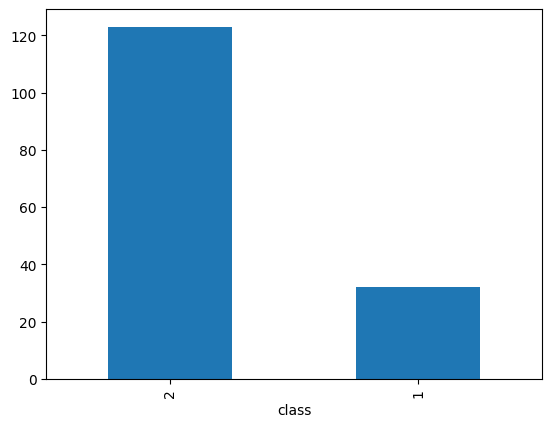

In [62]:
#Plotting
df['class'].value_counts().plot(kind= 'bar')

In [63]:
target_value = {'male':1, 'female': 2 }

In [66]:
# Checking males and females(sex)

df['sex'].value_counts()

sex
1    139
2     16
Name: count, dtype: int64

<Axes: xlabel='sex'>

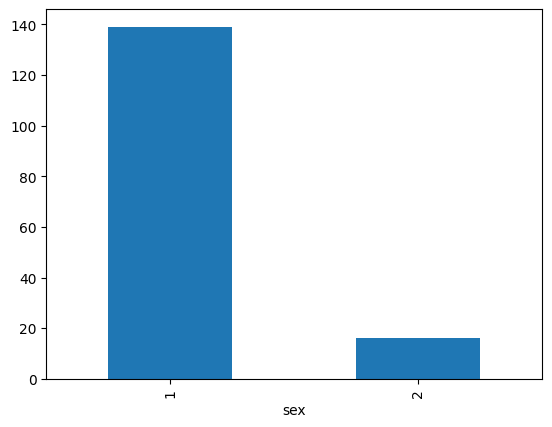

In [68]:
df['sex'].value_counts().plot(kind = 'bar')

# Narrative
- There are more males than females in the dataset

In [71]:
### Age range
df.groupby(["age", "sex"]).size()

age  sex
7    1      1
20   1      2
     2      1
22   1      1
     2      1
23   1      4
24   1      2
25   1      2
     2      1
26   2      1
27   1      4
28   1      4
     2      1
30   1      7
     2      1
31   1      4
32   1      4
33   1      3
34   1      6
     2      2
35   1      2
36   1      7
37   1      5
38   1      8
39   1      6
40   1      3
41   1      2
     2      1
42   1      5
43   1      1
44   1      5
45   1      4
     2      1
46   1      1
47   1      4
48   1      2
49   1      3
50   1      5
     2      1
51   1      6
52   1      3
53   2      1
54   1      5
56   1      3
57   1      2
58   1      1
     2      1
59   1      1
60   1      1
61   1      3
62   1      1
     2      1
64   1      1
65   1      1
66   1      1
67   2      1
69   2      1
70   1      1
72   1      1
78   1      1
dtype: int64

#### Frequency distribution table base on the insights from the Age range found above 




In [74]:
maxi =df["age"].max()
mini = df["age"].min()

print( 'The maximum age is =', maxi)
print( 'The minimum age is =', mini)

The maximum age is = 78
The minimum age is = 7


In [76]:
labels = ["Less than 10", "10-20","20-30","30-40","40-50","50-60","60-70","70 and more" ]
bins = [0,10,20,30,40,50,60,70,80]
freq_df = df.groupby(pd.cut(df['age'], bins = bins, labels = labels), observed= True).size()
freq_df

age
Less than 10     1
10-20            3
20-30           29
30-40           50
40-50           35
50-60           24
60-70           11
70 and more      2
dtype: int64

In [78]:
#Insights from this table will help in knowing most/least affected age group
freq_df = freq_df.reset_index(name='count')
freq_df


,age,count
0,Less than 10,1
1,10-20,3
2,20-30,29
3,30-40,50
4,40-50,35
5,50-60,24
6,60-70,11
7,70 and more,2


<Axes: >

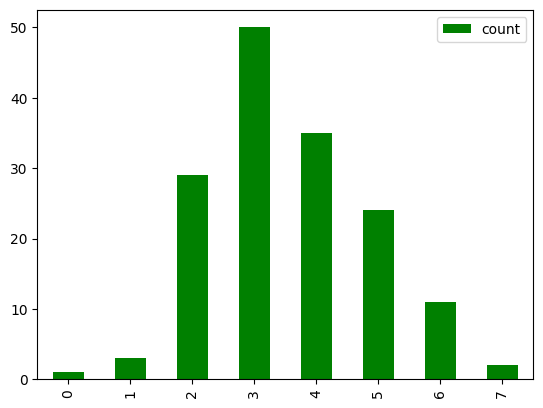

In [80]:
freq_df.plot(kind='bar', color='green')

<Axes: >

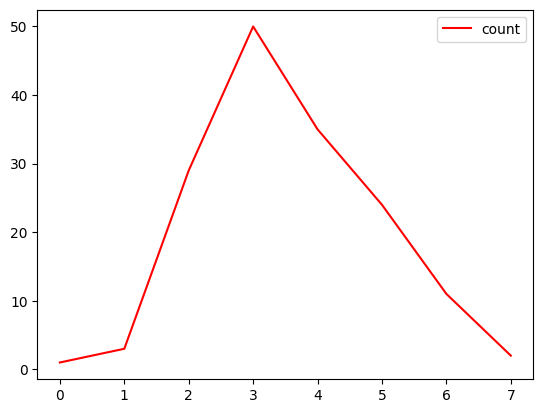

In [81]:
freq_df.plot(kind='line', color='red')

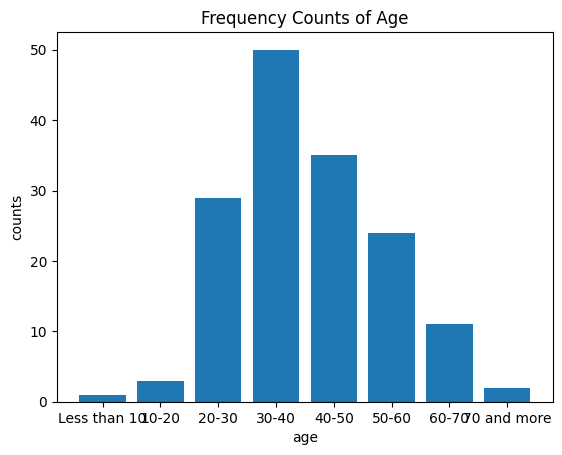

In [83]:
#Plotting of the freq table
plt.bar(freq_df['age'], freq_df['count'])
plt.ylabel('counts')
plt.xlabel('age')
plt.title('Frequency Counts of Age')
plt.show()

### Narrative
- Higest prevelence of the hepatitis infection is among people of age 30-40, follow by 50-60. It is noticed also that the least affected age group is people of Less than 10 years (children), follow by people of 70 years and above

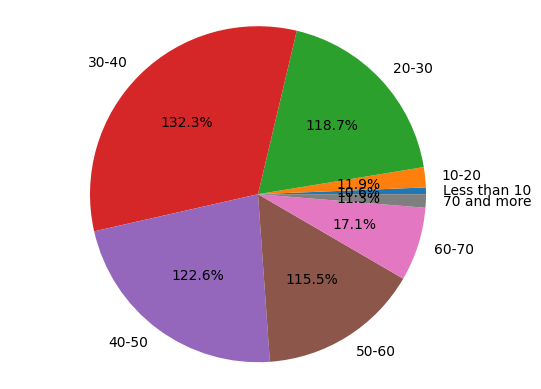

In [87]:
#Plotting data in pie chart
labels = ["Less than 10", "10-20","20-30","30-40","40-50","50-60","60-70","70 and more" ]
fiql,ax1 = plt.subplots()
ax1.pie(freq_df['count'], labels = labels, autopct='1%.1f%%')
ax1.axis('equal')
plt.show()

### Checking Outliers
- Univariant Analysis
Multivariante Analysis
#### Methods  used in these Analysis
- Boxplot(Uni)
- Scatterplot (Multi)
- Z-score
- IQR Interquantile Range

<Axes: ylabel='age'>

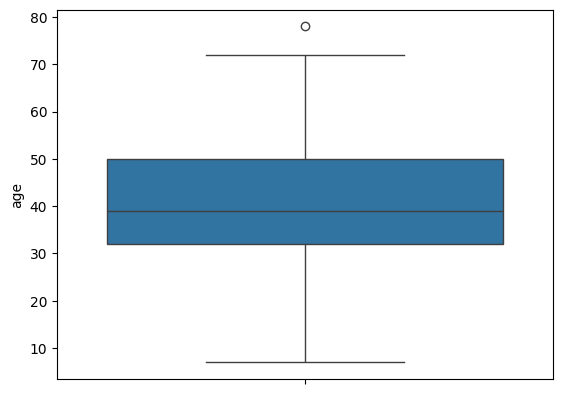

In [90]:
#Using Boxplot for Univariante Outlier Detection
sns.boxplot(df['age'])

In [91]:
df["age"] == 78

0      False
1      False
2       True
3      False
4      False
       ...  
150    False
151    False
152    False
153    False
154    False
Name: age, Length: 155, dtype: bool

In [94]:
df[df["age"] ==78]

,class,age,sex,steroid,antivirals,fatigue,malaise,anorexia,liver _ big,liver _ firm,spleen _ palpable,spiders,ascites,varices,bilirubin,alk _ phosphate,sgot,albumin,protime,histology
2,2,78,1,2,2,1,2,2,2,2,2,2,2,2,0.7,96,32,4.0,0,1


<Axes: ylabel='steroid'>

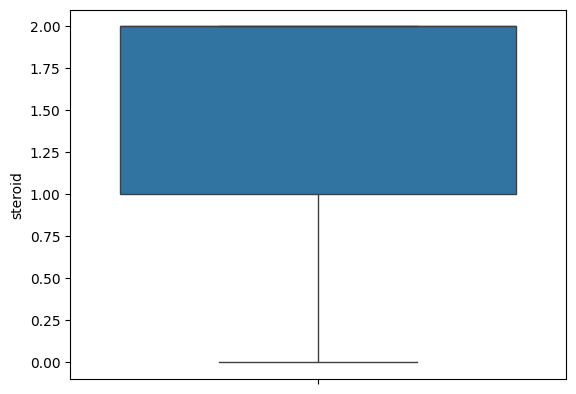

In [96]:
sns.boxplot(df["steroid"])

In [97]:
Q1 = df["steroid"].quantile(0.25)
Q3 = df["steroid"].quantile(0.75)
print(Q1, Q3)
IQR = Q3 - Q1

print("IQR=", IQR)

1.0 2.0
IQR= 1.0


In [100]:
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 - 1.5 * IQR

In [102]:
outliers = df[(df["steroid"] < lower_bound)] |  df[(df["steroid"] > upper_bound)]
outliers

,class,age,sex,steroid,antivirals,fatigue,malaise,anorexia,liver _ big,liver _ firm,spleen _ palpable,spiders,ascites,varices,bilirubin,alk _ phosphate,sgot,albumin,protime,histology
0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
5,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
150,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
151,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
152,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
153,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False


<Axes: ylabel='albumin'>

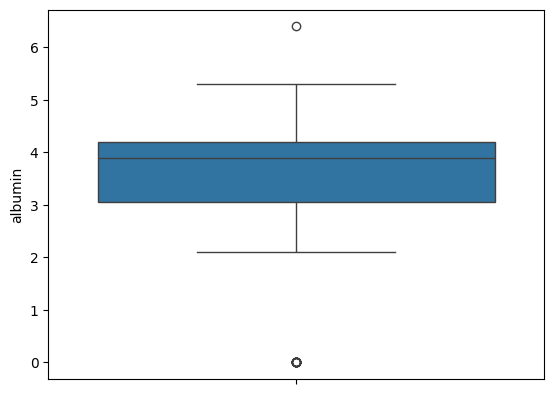

In [104]:
sns.boxplot(df["albumin"])

<Axes: xlabel='age', ylabel='albumin'>

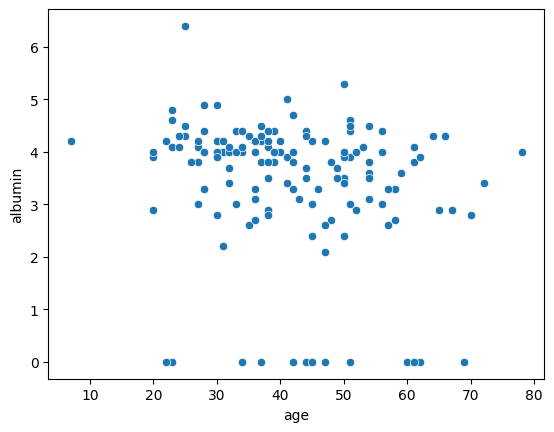

In [106]:
#Using Scatterplot to detect outliers

sns.scatterplot(x=df['age'], y=df['albumin'])

<Axes: xlabel='age', ylabel='albumin'>

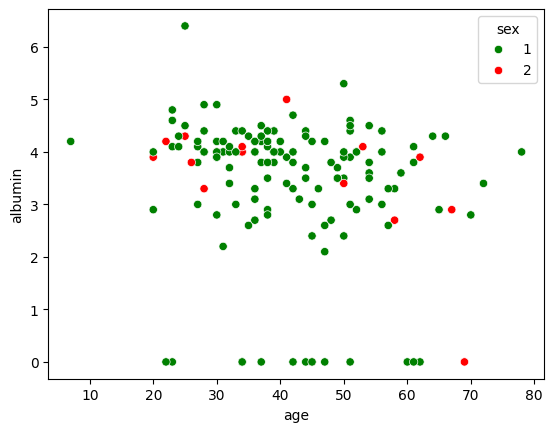

In [107]:
sns.scatterplot( data = df,  x = df["age"], y = df["albumin"], hue=df["sex"], palette = ["green" , "red"])

# Calculating quantile Range(IQR),Q1, and Q3; 
- H-Spread/Mid_spread
- Measures the satistical dispersion
- IQR = Quantile Q3( 0.75) - Q1 ( 0.25)


In [111]:
Q1 = df.quantile(0.25)
Q2 = df.quantile(0.50)  # This is the median
Q3 = df.quantile(0.75)
IQR = Q3 - Q1
IQR

outliers = (df < (Q1 - 1.5* IQR)) | (df >(Q3-1.5 * IQR))
outliers

# Display them
#print("Q1:", Q1)
#print("Q2 (Median):", Q2)
#print("Q3:", Q3)
#print("Lower Bound:", lower_bound)
#print("Upper Bound:", upper_bound)
#print("Outliers:\n", outliers)


,class,age,sex,steroid,antivirals,fatigue,malaise,anorexia,liver _ big,liver _ firm,spleen _ palpable,spiders,ascites,varices,bilirubin,alk _ phosphate,sgot,albumin,protime,histology
0,False,True,True,True,False,True,True,False,True,True,False,True,False,False,True,True,True,True,True,True
1,False,True,False,True,False,True,True,False,True,True,False,True,False,False,True,True,True,True,True,True
2,False,True,False,True,False,True,True,False,False,True,False,True,False,False,True,True,True,True,True,True
3,False,True,False,False,True,True,True,False,False,True,False,True,False,False,True,True,True,True,True,True
4,False,True,False,True,False,True,True,False,False,True,False,True,False,False,True,False,True,True,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
150,True,True,False,True,False,True,True,True,False,True,False,True,True,True,True,False,True,True,True,True
151,False,True,False,True,False,True,True,False,False,True,False,True,False,False,True,True,True,True,True,True
152,False,True,False,True,False,True,True,False,True,True,False,True,False,False,True,True,True,True,True,True
153,False,True,True,True,False,True,True,False,False,True,True,True,False,True,True,True,True,True,True,True


#Narrative
- data points with 'true' are outliers

## Solution
- Remove them
- Clean 
- Ignore

In [115]:
#Removing
df_no_outliers = df[~((df < (Q1 - 1.5 * IQR)) | (df >(Q3 + 1.5 * IQR))).any(axis=1)]
df_no_outliers

,class,age,sex,steroid,antivirals,fatigue,malaise,anorexia,liver _ big,liver _ firm,spleen _ palpable,spiders,ascites,varices,bilirubin,alk _ phosphate,sgot,albumin,protime,histology
4,2,34,1,2,2,2,2,2,2,2,2,2,2,2,1.0,0,200,4.0,0,1
5,2,34,1,2,2,2,2,2,2,2,2,2,2,2,0.9,95,28,4.0,75,1
8,2,39,1,2,2,1,2,2,2,1,2,2,2,2,0.7,0,48,4.4,0,1
9,2,30,1,2,2,2,2,2,2,2,2,2,2,2,1.0,0,120,3.9,0,1
13,2,30,1,2,2,1,2,2,2,1,2,2,2,2,2.2,57,144,4.9,78,1
16,2,66,1,2,2,1,2,2,2,2,2,2,2,2,1.2,102,53,4.3,0,1
17,2,40,1,1,2,1,2,2,2,1,2,2,2,2,0.6,62,166,4.0,63,1
18,2,38,1,2,2,2,2,2,2,2,2,2,2,2,0.7,53,42,4.1,85,2
22,2,31,1,2,2,2,2,2,2,2,2,2,2,2,1.0,85,20,4.0,100,1
23,2,42,1,2,2,2,2,2,2,2,2,2,2,2,0.9,60,63,4.7,47,1


In [117]:
print(df.shape)
print(df_no_outliers.shape)

(155, 20)
(43, 20)


In [119]:
df_no_outliers.describe()

,class,age,sex,steroid,antivirals,fatigue,malaise,anorexia,liver _ big,liver _ firm,spleen _ palpable,spiders,ascites,varices,bilirubin,alk _ phosphate,sgot,albumin,protime,histology
count,43.0,43.000000,43.0,43.000000,43.0,43.000000,43.000000,43.0,43.0,43.000000,43.0,43.000000,43.0,43.0,43.000000,43.000000,43.000000,43.000000,43.000000,43.00000
mean,2.0,38.116279,1.0,1.627907,2.0,1.604651,1.883721,2.0,2.0,1.813953,2.0,1.953488,2.0,2.0,0.932558,72.604651,72.116279,4.104651,38.395349,1.27907
std,0.0,10.147036,0.0,0.489083,0.0,0.494712,0.324353,0.0,0.0,0.450175,0.0,0.213083,0.0,0.0,0.308391,39.498728,48.896494,0.443983,41.735642,0.45385
min,2.0,20.000000,1.0,1.000000,2.0,1.000000,1.000000,2.0,2.0,0.000000,2.0,1.000000,2.0,2.0,0.600000,0.000000,14.000000,2.900000,0.000000,1.00000
25%,2.0,30.000000,1.0,1.000000,2.0,1.000000,2.000000,2.0,2.0,2.000000,2.0,2.000000,2.0,2.0,0.700000,55.000000,32.000000,4.000000,0.000000,1.00000
50%,2.0,37.000000,1.0,2.000000,2.0,2.000000,2.000000,2.0,2.0,2.000000,2.0,2.000000,2.0,2.0,0.900000,82.000000,60.000000,4.000000,0.000000,1.00000
75%,2.0,44.000000,1.0,2.000000,2.0,2.000000,2.000000,2.0,2.0,2.000000,2.0,2.000000,2.0,2.0,1.000000,97.500000,96.000000,4.350000,74.500000,2.00000
max,2.0,66.000000,1.0,2.000000,2.0,2.000000,2.000000,2.0,2.0,2.000000,2.0,2.000000,2.0,2.0,2.200000,147.000000,200.000000,5.300000,100.000000,2.00000


In [121]:
# Step 1: Calculate IQR ------- Same as the code above
Q1 = df.quantile(0.25)
Q3 = df.quantile(0.75)
IQR = Q3 - Q1

# Step 2: Define bounds
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

# Step 3: Keep only rows with all values within bounds
df_no_outliers1 = df[(df >= lower) & (df <= upper)].dropna()
df_no_outliers1


,class,age,sex,steroid,antivirals,fatigue,malaise,anorexia,liver _ big,liver _ firm,spleen _ palpable,spiders,ascites,varices,bilirubin,alk _ phosphate,sgot,albumin,protime,histology
4,2.0,34.0,1.0,2,2.0,2,2,2.0,2.0,2,2.0,2,2.0,2.0,1.0,0.0,200.0,4.0,0,1
5,2.0,34.0,1.0,2,2.0,2,2,2.0,2.0,2,2.0,2,2.0,2.0,0.9,95.0,28.0,4.0,75,1
8,2.0,39.0,1.0,2,2.0,1,2,2.0,2.0,1,2.0,2,2.0,2.0,0.7,0.0,48.0,4.4,0,1
9,2.0,30.0,1.0,2,2.0,2,2,2.0,2.0,2,2.0,2,2.0,2.0,1.0,0.0,120.0,3.9,0,1
13,2.0,30.0,1.0,2,2.0,1,2,2.0,2.0,1,2.0,2,2.0,2.0,2.2,57.0,144.0,4.9,78,1
16,2.0,66.0,1.0,2,2.0,1,2,2.0,2.0,2,2.0,2,2.0,2.0,1.2,102.0,53.0,4.3,0,1
17,2.0,40.0,1.0,1,2.0,1,2,2.0,2.0,1,2.0,2,2.0,2.0,0.6,62.0,166.0,4.0,63,1
18,2.0,38.0,1.0,2,2.0,2,2,2.0,2.0,2,2.0,2,2.0,2.0,0.7,53.0,42.0,4.1,85,2
22,2.0,31.0,1.0,2,2.0,2,2,2.0,2.0,2,2.0,2,2.0,2.0,1.0,85.0,20.0,4.0,100,1
23,2.0,42.0,1.0,2,2.0,2,2,2.0,2.0,2,2.0,2,2.0,2.0,0.9,60.0,63.0,4.7,47,1


In [123]:
print(df_no_outliers1.shape)

(43, 20)


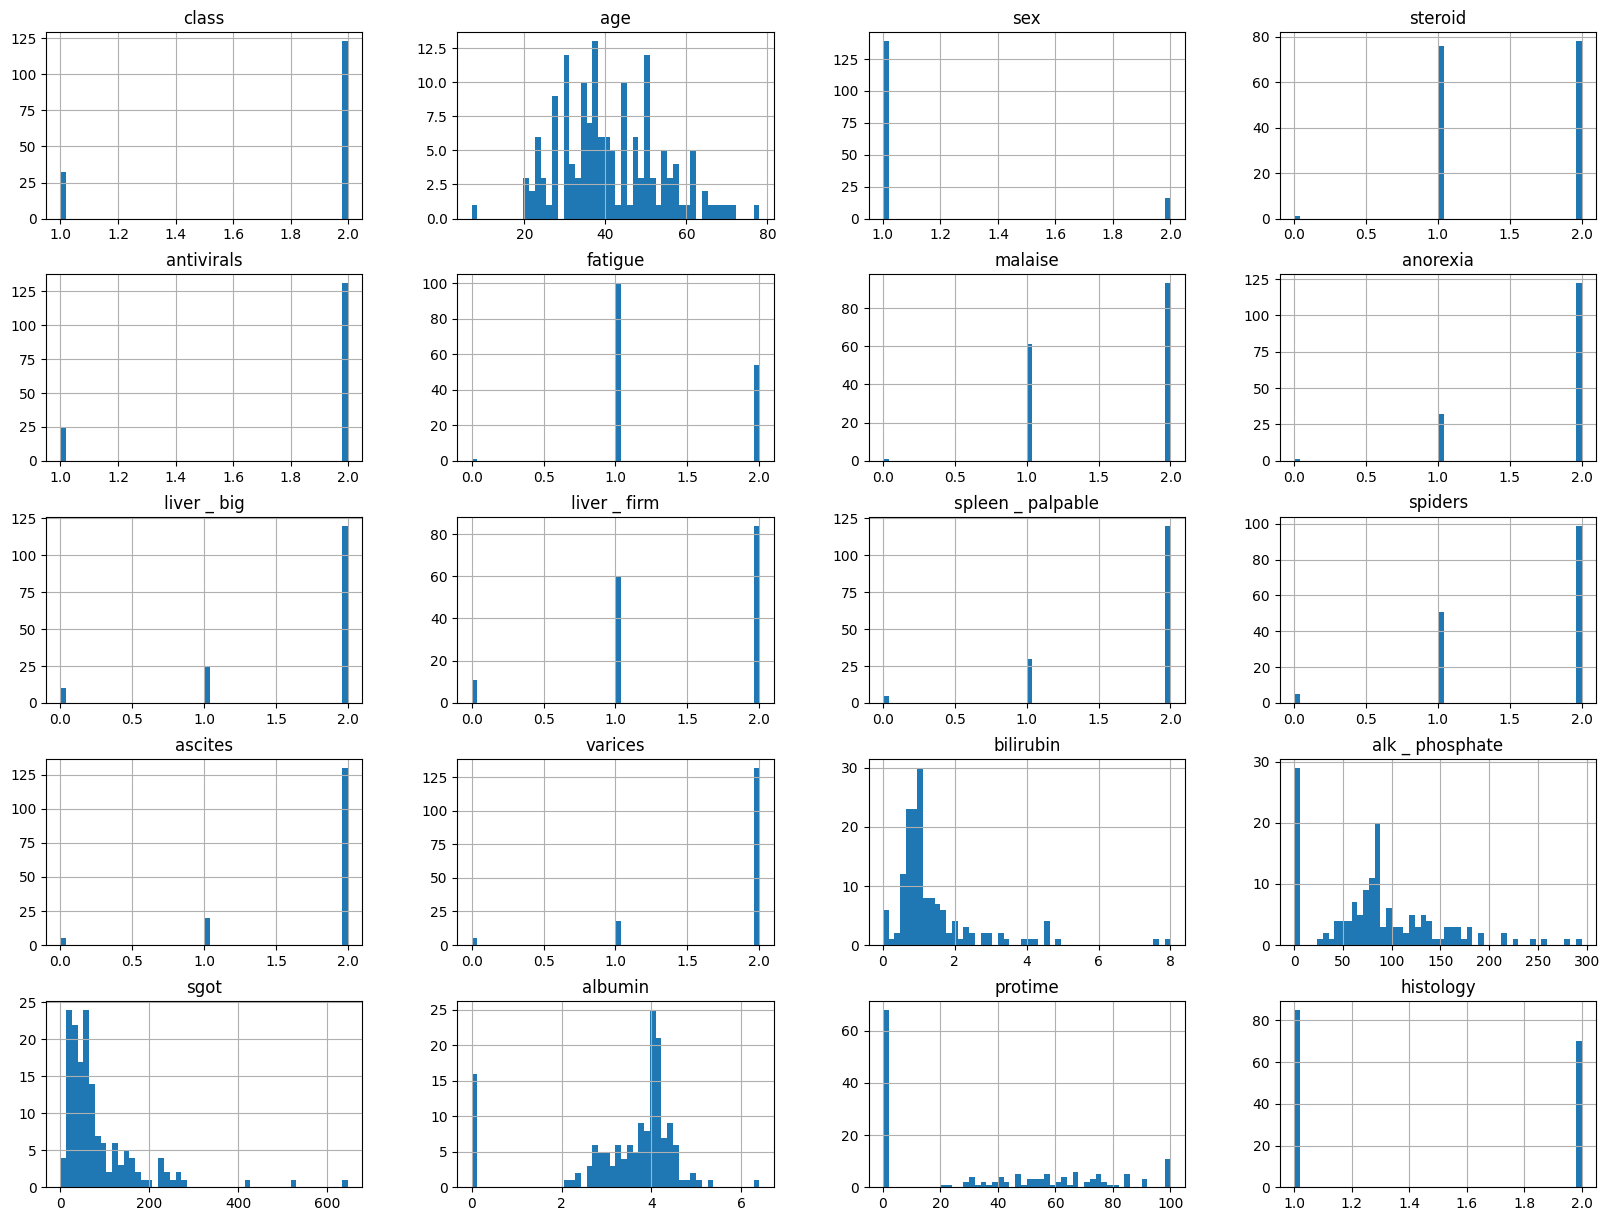

In [125]:
#Plotting of distribution of data
df.hist(bins=50, figsize=(20,15))
plt.show()

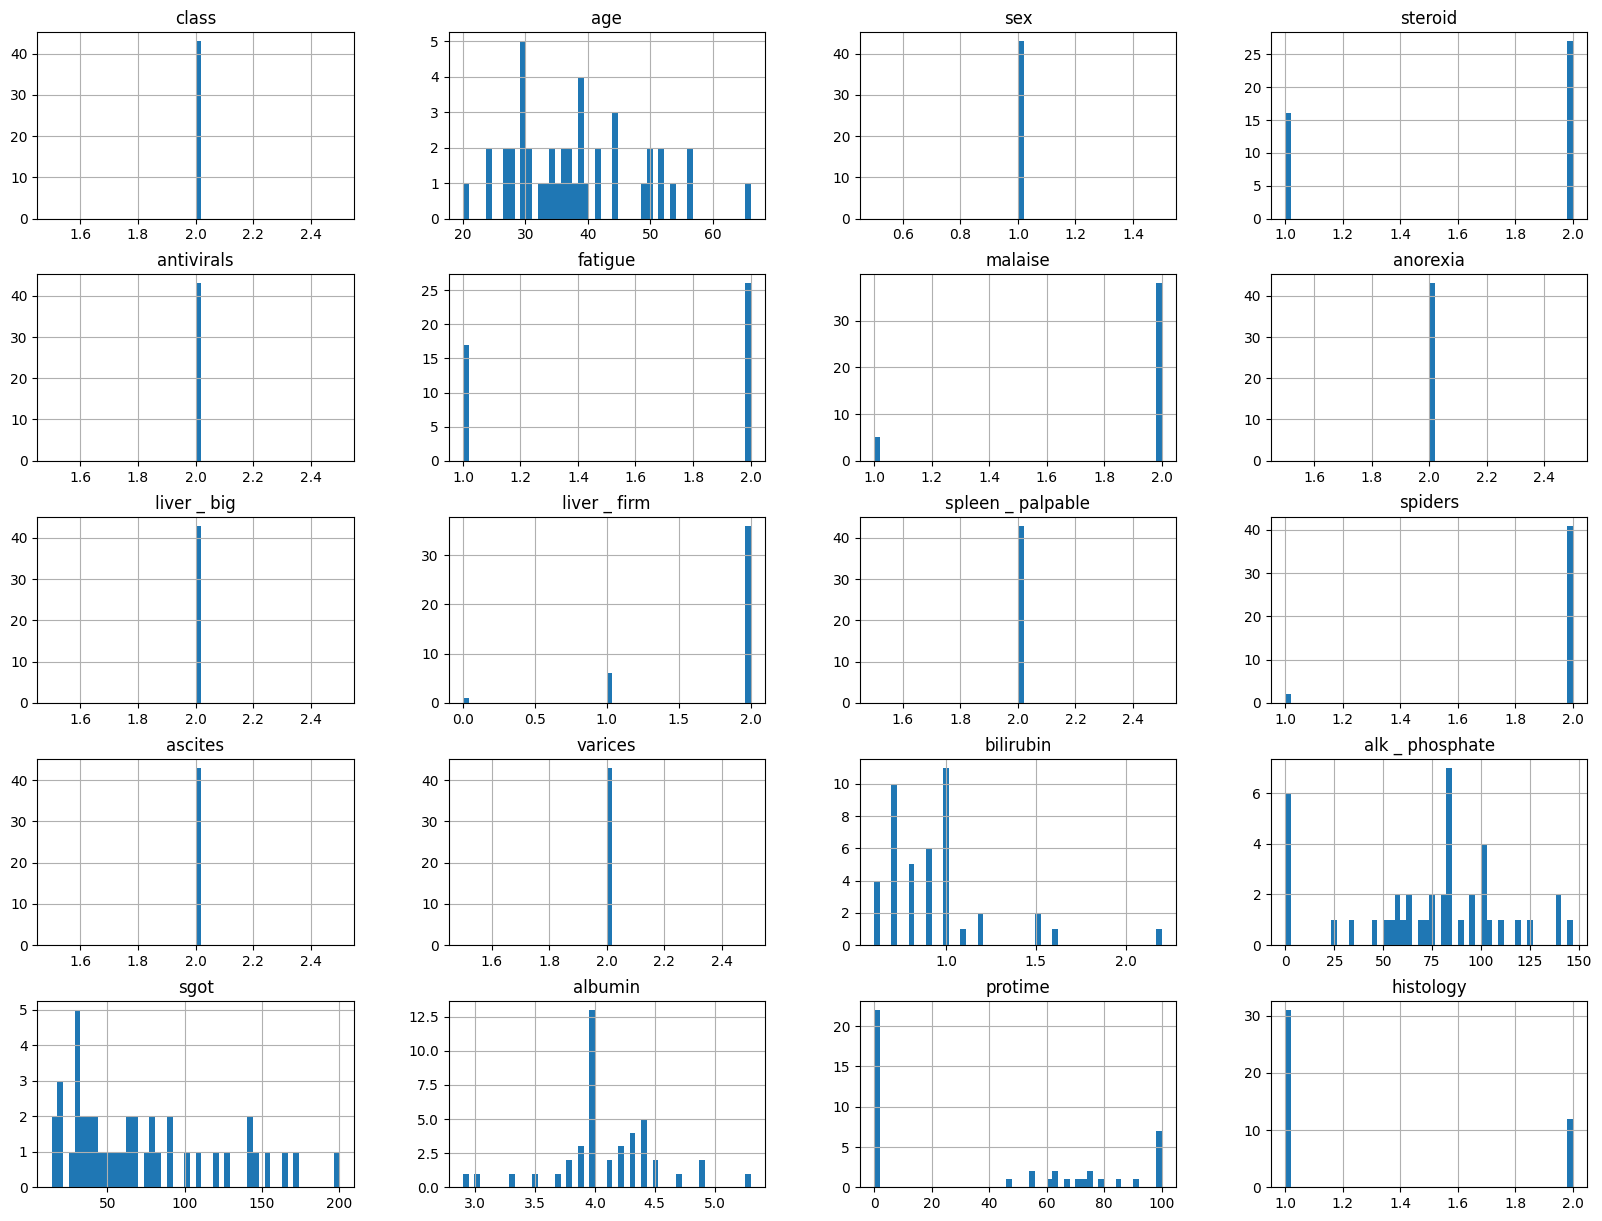

In [126]:
#Plotting of distribution of outliers of the data
df_no_outliers.hist(bins=50, figsize=(20,15))
plt.show()

#### Feature Selection and Importance 
- SelectKbest
    - Strong relation with our target/output
- Recursive Featuure Elimination

In [128]:
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import chi2

In [129]:
## Features and labels
df.head()

,class,age,sex,steroid,antivirals,fatigue,malaise,anorexia,liver _ big,liver _ firm,spleen _ palpable,spiders,ascites,varices,bilirubin,alk _ phosphate,sgot,albumin,protime,histology
0,2,30,2,1,2,2,2,2,1,2,2,2,2,2,1.0,85,18,4.0,0,1
1,2,50,1,1,2,1,2,2,1,2,2,2,2,2,0.9,135,42,3.5,0,1
2,2,78,1,2,2,1,2,2,2,2,2,2,2,2,0.7,96,32,4.0,0,1
3,2,31,1,0,1,2,2,2,2,2,2,2,2,2,0.7,46,52,4.0,80,1
4,2,34,1,2,2,2,2,2,2,2,2,2,2,2,1.0,0,200,4.0,0,1


In [130]:
df.columns

Index(['class', 'age', 'sex', 'steroid', 'antivirals', 'fatigue', 'malaise',
       'anorexia', 'liver _ big', 'liver _ firm', 'spleen _ palpable',
       'spiders', 'ascites', 'varices', 'bilirubin', 'alk _ phosphate', 'sgot',
       'albumin', 'protime', 'histology'],
      dtype='object')

In [131]:
xfeatures = df[['age', 'sex', 'steroid', 'antivirals', 'fatigue', 'malaise',
       'anorexia', 'liver _ big', 'liver _ firm', 'spleen _ palpable',
       'spiders', 'ascites', 'varices', 'bilirubin', 'alk _ phosphate', 'sgot',
       'albumin', 'protime', 'histology']]

ylabels = df['class']

In [132]:
##Using Skbest
# Step 1: Create the SelectKBest object
skb = SelectKBest(score_func=chi2, k=10)

# Step 2: Fit it to your data
best_feature_fit = skb.fit(xfeatures, ylabels)

In [133]:
## Note: The Hoighest score shows the best fit
print('Scores =', best_feature_fit.scores_)

Scores = [ 28.47481919   0.38948319   0.3995129    0.18634161   2.34643234
   2.46803203   0.19648065   0.31698209   0.9867095    0.74535155
   3.18940804   2.09639954   1.12812176  30.10247172  17.88270548
  47.38820795   6.87318606 130.18332457   3.01854675]


In [134]:
print(skb.scores_)

[ 28.47481919   0.38948319   0.3995129    0.18634161   2.34643234
   2.46803203   0.19648065   0.31698209   0.9867095    0.74535155
   3.18940804   2.09639954   1.12812176  30.10247172  17.88270548
  47.38820795   6.87318606 130.18332457   3.01854675]


In [135]:
bf_03 = skb.transform(xfeatures)
bf_03

array([[30. ,  2. ,  2. , ...,  4. ,  0. ,  1. ],
       [50. ,  1. ,  2. , ...,  3.5,  0. ,  1. ],
       [78. ,  1. ,  2. , ...,  4. ,  0. ,  1. ],
       ...,
       [61. ,  1. ,  1. , ...,  4.1,  0. ,  2. ],
       [53. ,  1. ,  2. , ...,  4.1, 48. ,  2. ],
       [43. ,  1. ,  2. , ...,  3.1, 42. ,  2. ]])

In [136]:
bf_02 = best_feature_fit.transform(xfeatures)
bf_02

array([[30. ,  2. ,  2. , ...,  4. ,  0. ,  1. ],
       [50. ,  1. ,  2. , ...,  3.5,  0. ,  1. ],
       [78. ,  1. ,  2. , ...,  4. ,  0. ,  1. ],
       ...,
       [61. ,  1. ,  1. , ...,  4.1,  0. ,  2. ],
       [53. ,  1. ,  2. , ...,  4.1, 48. ,  2. ],
       [43. ,  1. ,  2. , ...,  3.1, 42. ,  2. ]])

In [137]:
#Mapping to Feature name 
feature_scores = pd.DataFrame(best_feature_fit.scores_, columns = ['Feature_Scores'])
feature_scores

,Feature_Scores
0,28.474819
1,0.389483
2,0.399513
3,0.186342
4,2.346432
5,2.468032
6,0.196481
7,0.316982
8,0.986710
9,0.745352


In [138]:
feature_column_name = pd.DataFrame(xfeatures.columns, columns = ['Feature_name'])
best_fit_df = pd.concat([feature_scores, feature_column_name], axis = 1)

In [139]:
best_fit_df

,Feature_Scores,Feature_name
0,28.474819,age
1,0.389483,sex
2,0.399513,steroid
3,0.186342,antivirals
4,2.346432,fatigue
5,2.468032,malaise
6,0.196481,anorexia
7,0.316982,liver _ big
8,0.986710,liver _ firm
9,0.745352,spleen _ palpable


In [140]:
# Getting the best ..... The higher the number, the more important the feature
best_fit_df.nlargest(10, 'Feature_Scores')

,Feature_Scores,Feature_name
17,130.183325,protime
15,47.388208,sgot
13,30.102472,bilirubin
0,28.474819,age
14,17.882705,alk _ phosphate
16,6.873186,albumin
10,3.189408,spiders
18,3.018547,histology
5,2.468032,malaise
4,2.346432,fatigue


In [141]:
best_fit_df.nlargest(12, 'Feature_Scores')

,Feature_Scores,Feature_name
17,130.183325,protime
15,47.388208,sgot
13,30.102472,bilirubin
0,28.474819,age
14,17.882705,alk _ phosphate
16,6.873186,albumin
10,3.189408,spiders
18,3.018547,histology
5,2.468032,malaise
4,2.346432,fatigue


In [142]:
best_fit_df.nlargest(12, 'Feature_Scores')['Feature_name'].unique()

array(['protime', 'sgot', 'bilirubin', 'age', 'alk _ phosphate',
       'albumin', 'spiders', 'histology', 'malaise', 'fatigue', 'ascites',
       'varices'], dtype=object)

### Recursive Feature Elimination

In [145]:
from sklearn.feature_selection import RFE
from sklearn.linear_model import LogisticRegression

In [146]:
logit = LogisticRegression()

In [147]:
rfe = RFE(estimator=logit, n_features_to_select=8)

In [148]:
rfe_fit = rfe.fit(xfeatures, ylabels)

/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_ite

In [149]:
#SELECTION 
selected_features = pd.DataFrame(rfe.support_, columns=['Selected_Features'])
ranking_features = pd.DataFrame(rfe.ranking_, columns=['ranking_Features'])

In [150]:
rfe_feature_df = pd.concat([feature_column_name, selected_features, ranking_features], axis=1)
rfe_feature_df

,Feature_name,Selected_Features,ranking_Features
0,age,False,8
1,sex,True,1
2,steroid,False,5
3,antivirals,False,9
4,fatigue,True,1
5,malaise,True,1
6,anorexia,True,1
7,liver _ big,False,4
8,liver _ firm,False,6
9,spleen _ palpable,False,7


### Narrative 
- RFE we will eliminate the lowest ranking or True features


### Checking for Feature Importance
- ExtraTreesClassifier
- Which feature is important

In [153]:
from sklearn.ensemble import ExtraTreesClassifier

In [154]:
# Init

et_clf = ExtraTreesClassifier()
et_clf.fit(xfeatures, ylabels)
# printing Important
print(et_clf.feature_importances_)

[0.06388117 0.02501173 0.02570557 0.01313339 0.03002441 0.04815831
 0.02646805 0.03688019 0.05584367 0.03960062 0.0760909  0.08774068
 0.05619833 0.09835636 0.06877704 0.05015092 0.07713983 0.06493225
 0.05590657]


In [155]:
feature_importance_df = pd.Series(et_clf.feature_importances_, index = xfeatures.columns)
feature_importance_df

age                  0.063881
sex                  0.025012
steroid              0.025706
antivirals           0.013133
fatigue              0.030024
malaise              0.048158
anorexia             0.026468
liver _ big          0.036880
liver _ firm         0.055844
spleen _ palpable    0.039601
spiders              0.076091
ascites              0.087741
varices              0.056198
bilirubin            0.098356
alk _ phosphate      0.068777
sgot                 0.050151
albumin              0.077140
protime              0.064932
histology            0.055907
dtype: float64

<Axes: >

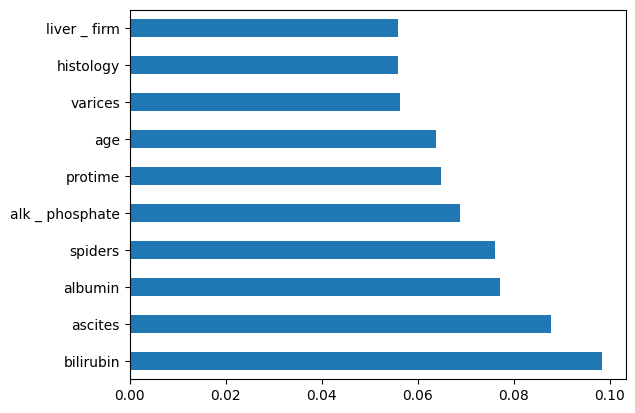

In [156]:
feature_importance_df.nlargest(10).plot(kind = 'barh')

In [170]:
selected_features = xfeatures.columns[rfe.support_]
print("Top 8 selected features:", selected_features.tolist())


Top 8 selected features: ['sex', 'fatigue', 'malaise', 'anorexia', 'spiders', 'bilirubin', 'albumin', 'histology']


### Narrative
- All methods used in getting the top/most importance features gave us almost same features to use

In [182]:
#Correlation
df.corr()

,class,age,sex,steroid,antivirals,fatigue,malaise,anorexia,liver _ big,liver _ firm,spleen _ palpable,spiders,ascites,varices,bilirubin,alk _ phosphate,sgot,albumin,protime,histology
class,1.000000,-0.219647,0.173051,0.121140,-0.130196,0.292206,0.315970,0.110715,0.102151,0.154736,0.180894,0.330194,0.332796,0.249610,-0.424523,-0.050806,-0.056679,0.296489,0.154688,-0.337856
age,-0.219647,1.000000,0.008126,-0.067710,-0.013100,-0.264635,-0.099516,0.100589,-0.126358,-0.100979,-0.127258,-0.206551,-0.125020,-0.114412,0.095626,0.045328,0.078021,-0.191174,-0.059956,0.170780
sex,0.173051,0.008126,1.000000,-0.039222,-0.089249,-0.063947,-0.020895,0.025186,0.023634,0.015750,-0.078414,-0.065592,0.049516,-0.005045,-0.039341,0.162851,-0.008991,-0.018906,0.067128,-0.137450
steroid,0.121140,-0.067710,-0.039222,1.000000,0.101657,0.146292,0.232041,0.084752,0.159877,0.095280,0.071401,0.029781,-0.002593,-0.029759,-0.005835,-0.042245,-0.021032,0.203109,0.032994,-0.070144
antivirals,-0.130196,-0.013100,-0.089249,0.101657,1.000000,-0.065578,-0.026703,-0.052554,-0.060626,-0.019871,-0.183070,-0.176367,-0.176382,-0.167721,0.177958,0.041764,0.095980,-0.153939,-0.276452,0.209242
fatigue,0.292206,-0.264635,-0.063947,0.146292,-0.065578,1.000000,0.617660,0.419991,0.168796,0.254621,0.226850,0.380935,0.288877,0.217311,-0.243964,-0.110505,-0.175476,0.198983,0.073783,-0.131177
malaise,0.315970,-0.099516,-0.020895,0.232041,-0.026703,0.617660,1.000000,0.631662,0.192556,0.197903,0.145236,0.376666,0.376182,0.267029,-0.269910,-0.114810,-0.177297,0.224605,0.067186,-0.116964
anorexia,0.110715,0.100589,0.025186,0.084752,-0.052554,0.419991,0.631662,1.000000,0.185164,0.144556,0.185004,0.371874,0.301514,0.288883,-0.244095,0.035984,-0.188183,0.133743,0.108322,-0.049702
liver _ big,0.102151,-0.126358,0.023634,0.159877,-0.060626,0.168796,0.192556,0.185164,1.000000,0.698517,0.338963,0.370229,0.339108,0.238645,-0.028856,0.018895,-0.026293,0.105555,0.174677,-0.104757
liver _ firm,0.154736,-0.100979,0.015750,0.095280,-0.019871,0.254621,0.197903,0.144556,0.698517,1.000000,0.322955,0.407114,0.310338,0.295100,-0.069352,-0.179977,-0.149876,0.059700,0.083312,-0.206632


<Axes: >

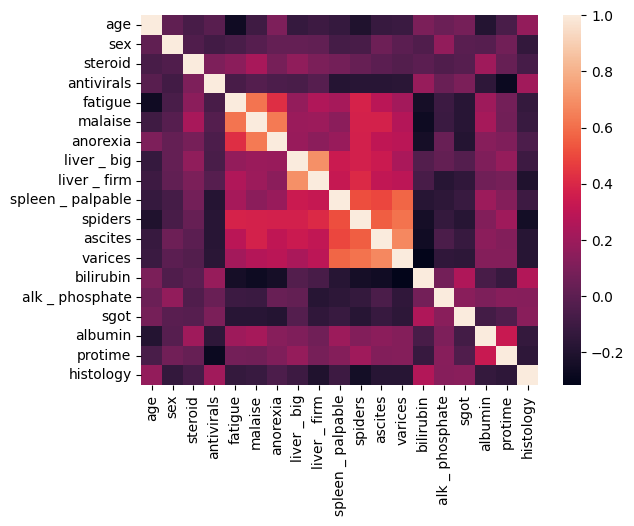

In [185]:
# Correlation Heatmap

sns.heatmap(xfeatures.corr())

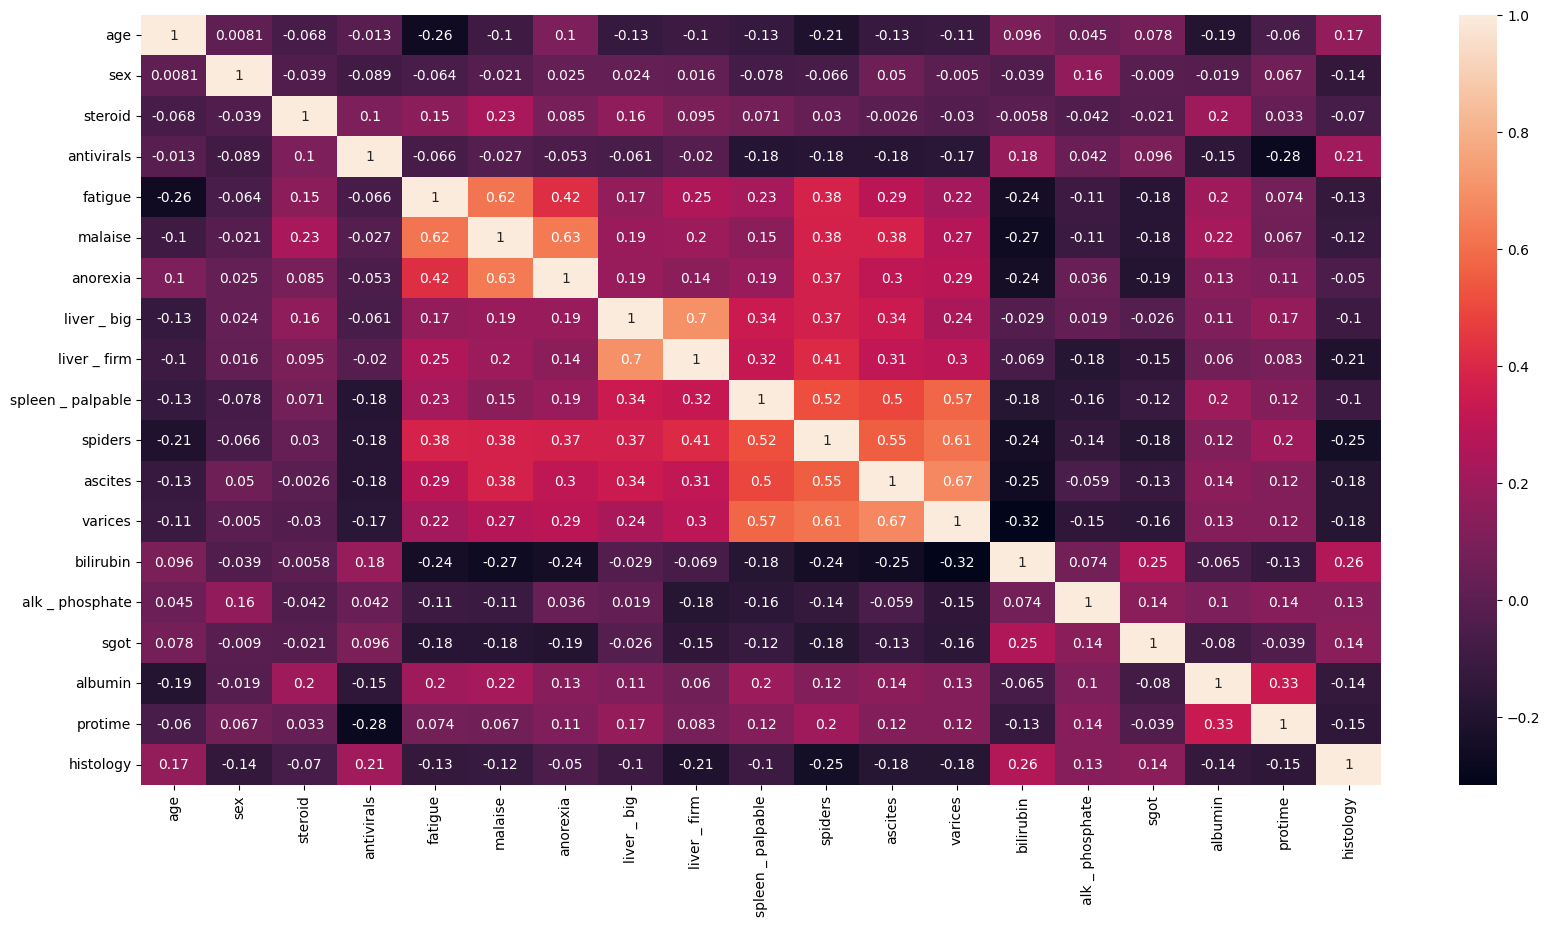

In [187]:
# Correlation Heatmap with annotation
plt.figure(figsize=(20,10))
sns.heatmap(xfeatures.corr(), annot=True)
plt.show()

### Model Building
- Feature and Labels
- Split/Train/Test
- LogisticRegression
- Random Forest
- Decision Tree
- Serialize

In [190]:
# ML Pkg importation
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier

# Metrics
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split

In [191]:
# Features for Initial data
df.columns

Index(['class', 'age', 'sex', 'steroid', 'antivirals', 'fatigue', 'malaise',
       'anorexia', 'liver _ big', 'liver _ firm', 'spleen _ palpable',
       'spiders', 'ascites', 'varices', 'bilirubin', 'alk _ phosphate', 'sgot',
       'albumin', 'protime', 'histology'],
      dtype='object')

In [192]:
xfeatures

,age,sex,steroid,antivirals,fatigue,malaise,anorexia,liver _ big,liver _ firm,spleen _ palpable,spiders,ascites,varices,bilirubin,alk _ phosphate,sgot,albumin,protime,histology
0,30,2,1,2,2,2,2,1,2,2,2,2,2,1.0,85,18,4.0,0,1
1,50,1,1,2,1,2,2,1,2,2,2,2,2,0.9,135,42,3.5,0,1
2,78,1,2,2,1,2,2,2,2,2,2,2,2,0.7,96,32,4.0,0,1
3,31,1,0,1,2,2,2,2,2,2,2,2,2,0.7,46,52,4.0,80,1
4,34,1,2,2,2,2,2,2,2,2,2,2,2,1.0,0,200,4.0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
150,46,1,2,2,1,1,1,2,2,2,1,1,1,7.6,0,242,3.3,50,2
151,44,1,2,2,1,2,2,2,1,2,2,2,2,0.9,126,142,4.3,0,2
152,61,1,1,2,1,1,2,1,1,2,1,2,2,0.8,75,20,4.1,0,2
153,53,2,1,2,1,2,2,2,2,1,1,2,1,1.5,81,19,4.1,48,2


In [193]:
ylabels = df['class']

In [195]:
# Selected Features
df.columns

Index(['class', 'age', 'sex', 'steroid', 'antivirals', 'fatigue', 'malaise',
       'anorexia', 'liver _ big', 'liver _ firm', 'spleen _ palpable',
       'spiders', 'ascites', 'varices', 'bilirubin', 'alk _ phosphate', 'sgot',
       'albumin', 'protime', 'histology'],
      dtype='object')

In [196]:
xfeatures_best = df[['age', 'sex', 'steroid', 'antivirals', 'fatigue',
       'spiders', 'ascites', 'varices', 'bilirubin', 'alk _ phosphate', 'sgot',
       'albumin', 'protime', 'histology']]

In [198]:
x_train, x_test, y_train, y_test = train_test_split(xfeatures, ylabels, test_size=0.30, random_state=7)

In [199]:
# train / test dataset for best features
x_train_b, x_test_b, y_train_b, y_test_b = train_test_split(xfeatures_best, ylabels, test_size=0.30, random_state=7)

In [200]:
#Building Model(LogisticReg)

logreg =  LogisticRegression()
logreg.fit(x_train, y_train)


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [204]:
# Model Accuracy, Method 1

logreg.score(x_test, y_test)


0.723404255319149

In [213]:
# Method 2
logreg.predict(x_test)

array([2, 2, 2, 2, 2, 1, 2, 2, 2, 2, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 2, 2, 2, 2, 2, 2,
       2, 2, 2])

In [214]:
print(list(y_test))

[2, 1, 2, 2, 2, 1, 1, 2, 2, 2, 1, 1, 2, 2, 2, 2, 1, 2, 2, 1, 2, 2, 1, 2, 2, 2, 1, 2, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 1, 2, 1, 2]


In [216]:
accuracy_score(y_test, logreg.predict(x_test))

0.723404255319149

In [219]:
#Building Model

model_logit =  LogisticRegression()
model_logit.fit(x_train_b, y_train_b)


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [221]:
model_logit.score(x_test_b, y_test_b)

0.723404255319149

In [223]:
#mMethd 2
model_logit.predict(x_test_b)

array([2, 2, 2, 2, 2, 1, 2, 2, 2, 2, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 2, 2, 2, 2, 2, 2,
       2, 2, 2])

In [225]:
## A single Prediction with Logreg
x_test.iloc[1]

age                   58.0
sex                    1.0
steroid                2.0
antivirals             2.0
fatigue                1.0
malaise                2.0
anorexia               2.0
liver _ big            1.0
liver _ firm           1.0
spleen _ palpable      1.0
spiders                1.0
ascites                2.0
varices                2.0
bilirubin              2.0
alk _ phosphate      167.0
sgot                 242.0
albumin                3.3
protime                0.0
histology              1.0
Name: 76, dtype: float64

In [227]:
res_dic = {"Die" : 1, "Live" : 2}
x1 = x_test.iloc[1]

In [229]:
# Reshaping
logreg.predict(np.array(x1).reshape(1, -1))

/opt/anaconda3/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


array([2])

### Alternative Alogorithms


In [232]:
clf = DecisionTreeClassifier()
clf.fit(x_train_b, y_train_b)

DecisionTreeClassifier()

In [234]:
 #Model Accuracy, Method 1

clf.score(x_test_b, y_test_b)


0.7659574468085106

In [236]:
clf.predict(x_test_b)

array([2, 2, 1, 2, 2, 1, 1, 2, 2, 2, 1, 1, 1, 2, 1, 2, 2, 2, 2, 1, 2, 2,
       2, 2, 2, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 2,
       2, 2, 2])

In [238]:
# KNN
from sklearn.neighbors import KNeighborsClassifier

In [240]:
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(x_train_b, y_train_b)

KNeighborsClassifier(n_neighbors=3)

In [242]:
knn.score(x_test_b, y_test_b)

0.7446808510638298

#### DecisionTree and KNN gave higher accuracy compared to Logreg

### Save the Model
- Serialization
- Pickle
- Joblib
- numpy/json

In [246]:
# Using Joblib
import joblib

In [248]:
model_file = open("logistic_regression_hepB_model.pkl", "wb")
joblib.dump(model_logit, model_file)
model_file.close()

In [250]:
model_file_knn = open("knn_hepB_model.pk", "wb")
joblib.dump(knn, model_file_knn)
model_file_knn.close()

In [252]:
model_file_clf = open("decision_tree_clf_hepB_model.pkl", "wb")
joblib.dump(clf, model_file_clf)
model_file_clf.close()

In [254]:
pip install pydotplus

Note: you may need to restart the kernel to use updated packages.


In [256]:
#Create Decision Tree Plot

from IPython.display import Image
from sklearn import tree
import pydotplus

In [257]:
feature_names_best = xfeatures_best.columns
target_names = ["Die", "Live"]

In [258]:
# Creating a Dot Plot
dot_data = tree.export_graphviz(clf,out_file=None, feature_names = feature_names_best, class_names = target_names)

In [259]:
# Drawing a Graph
graph = pydotplus.graph_from_dot_data(dot_data)

In [260]:
graph

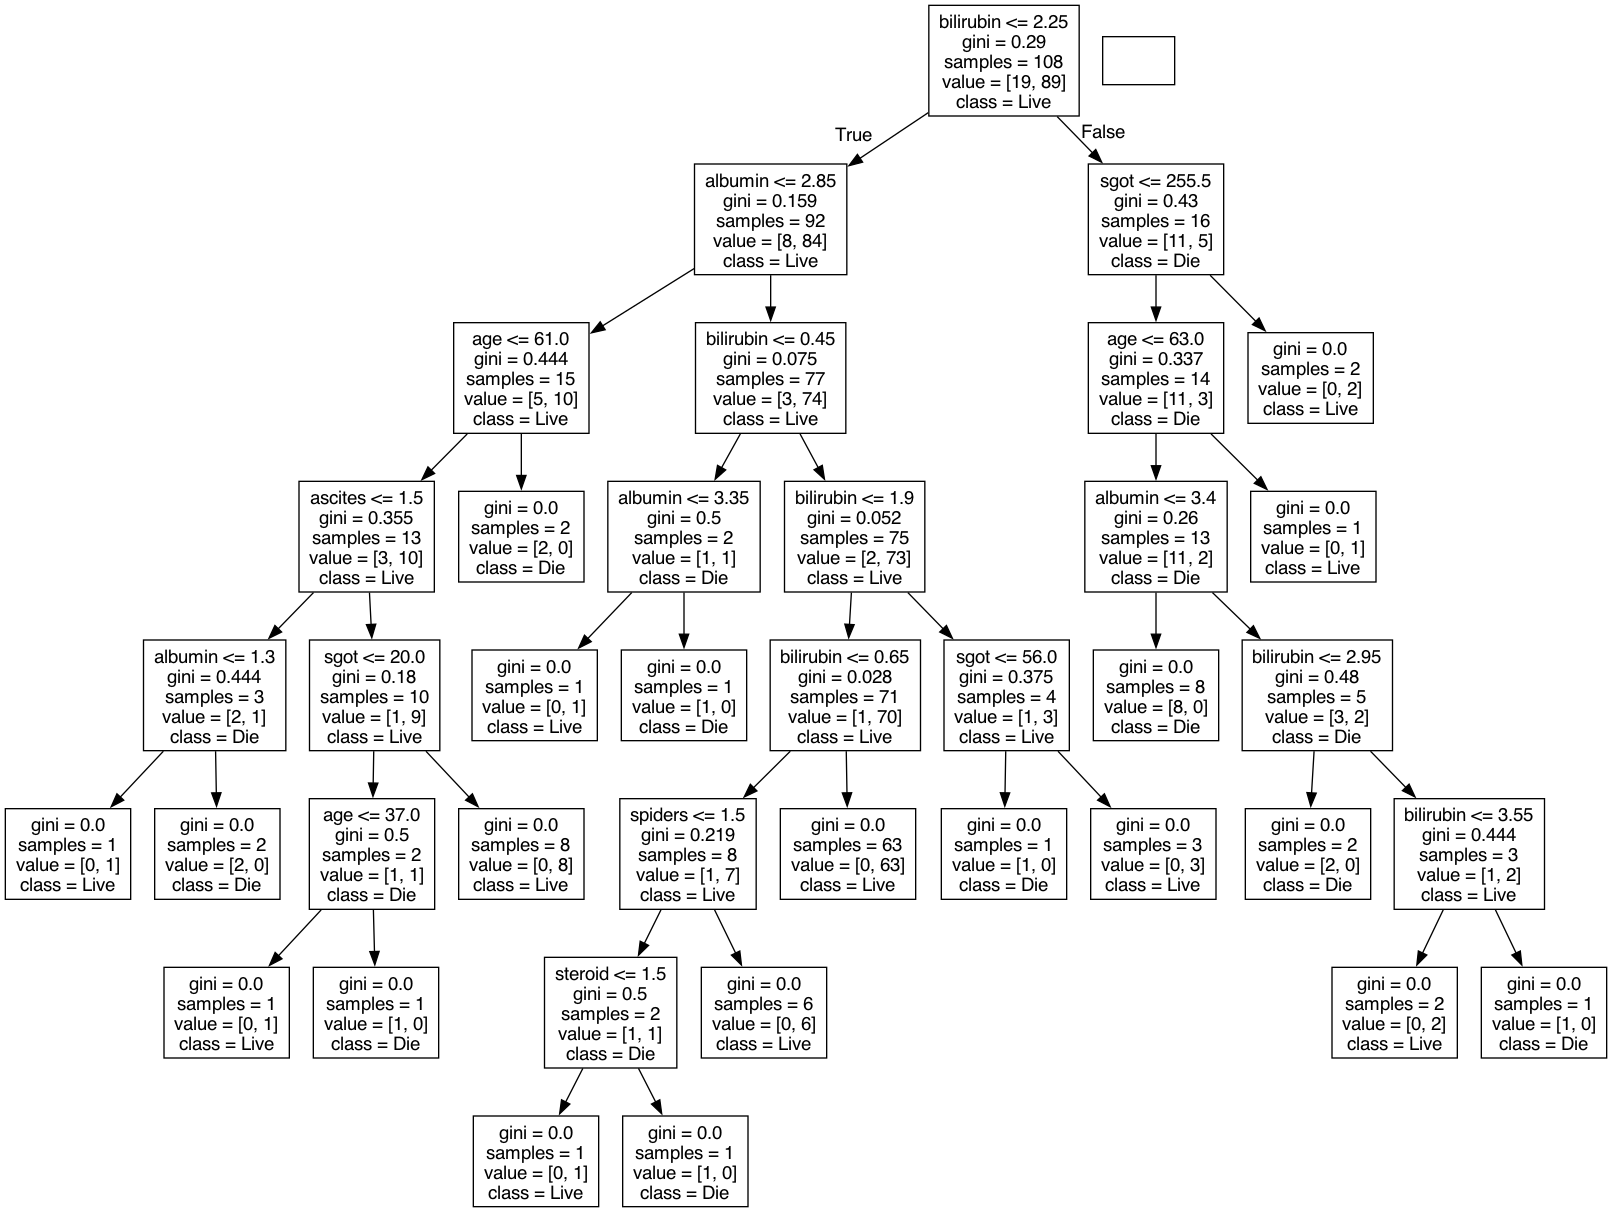

In [262]:
Image(graph.create_png())

In [268]:
# Saving the plot
graph.write_png("hep_decision_tree_plot.png")

True

### Interpreting & Evaluating the Model
- Eli5
- Lime
- SHAP
- Skater

In [270]:
!pip install lime

In [271]:
# we're using only 2 of the above

# Lime
import lime
import lime.lime_tabular

In [272]:
# Methods and Attributes

dir(lime)

['__builtins__',
 '__cached__',
 '__doc__',
 '__file__',
 '__loader__',
 '__name__',
 '__package__',
 '__path__',
 '__spec__',
 'discretize',
 'exceptions',
 'explanation',
 'lime_base',
 'lime_tabular']

## Create Lime Explainer
- LimeTabularExplainer = Tables
- LimeTextExlainer = Text
- LimeImageExplainer = Images

In [304]:
feature_names_best

Index(['age', 'sex', 'steroid', 'antivirals', 'fatigue', 'spiders', 'ascites',
       'varices', 'bilirubin', 'alk _ phosphate', 'sgot', 'albumin', 'protime',
       'histology'],
      dtype='object')

In [306]:
target_names

['Die', 'Live']

In [308]:
class_names = ["Die(1)", "Live(2)"]


In [318]:
# Create Explainer
explainer = lime.lime_tabular.LimeTabularExplainer(x_train_b.values, 
                                                   feature_names=feature_names_best,
                                                  class_names = class_names, 
                                                   discretize_continuous = True
                                                  )

In [320]:
x_test_b.iloc[1]

age                 58.0
sex                  1.0
steroid              2.0
antivirals           2.0
fatigue              1.0
spiders              1.0
ascites              2.0
varices              2.0
bilirubin            2.0
alk _ phosphate    167.0
sgot               242.0
albumin              3.3
protime              0.0
histology            1.0
Name: 76, dtype: float64

In [322]:
  # example indexes

explainer = lime.lime_tabular.LimeTabularExplainer(
    x_train_b.values,
    feature_names=feature_names_best,
    class_names=class_names,
    discretize_continuous=True
)


In [324]:
model_logit.predict(np.array(x_test_b.iloc[1]).reshape(1, -1))

/opt/anaconda3/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


array([2])

In [326]:
exp = explainer.explain_instance(
    x_test_b.iloc[1].values,
    model_logit.predict_proba,
    num_features=14,
    top_labels=1
)


/opt/anaconda3/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


In [328]:
exp.show_in_notebook(show_table=True, show_all=False)

In [330]:
# Explanation as List

exp.as_list()

[('bilirubin > 1.50', -0.41989414090391447),
 ('sex <= 1.00', -0.22773404755600327),
 ('spiders <= 1.00', -0.13615288500405862),
 ('histology <= 1.00', 0.11530852702890881),
 ('sgot > 90.50', 0.10504338326438954),
 ('alk _ phosphate > 119.25', -0.09795962994189687),
 ('age > 50.25', -0.06191422734029972),
 ('protime <= 0.00', 0.04149967109854166),
 ('2.98 < albumin <= 4.00', 0.039013473379799594),
 ('fatigue <= 1.00', 0.03276574766546604),
 ('1.50 < steroid <= 2.00', 0.03170765246234168),
 ('antivirals <= 2.00', 0.0),
 ('ascites <= 2.00', 0.0),
 ('varices <= 2.00', 0.0)]

In [288]:
!pip install eli5

In [289]:
### Using Eli5
#import warnings
#warnings.filterwarnings('ignore') # trying to hide warnings that comes with eli5 import
import eli5

In [340]:
feature_names_best = ['age', 'sex', 'steroid', 'antivirals', 'fatigue', 'spiders', 'ascites',
       'varices', 'bilirubin', 'alk _ phosphate', 'sgot', 'albumin', 'protime',
       'histology']
feature_names_best

['age',
 'sex',
 'steroid',
 'antivirals',
 'fatigue',
 'spiders',
 'ascites',
 'varices',
 'bilirubin',
 'alk _ phosphate',
 'sgot',
 'albumin',
 'protime',
 'histology']

In [342]:
# Showing how each feature contributes

eli5.show_weights(model_logit, feature_names = feature_names_best, target_names = class_names, top=10)

In [344]:
eli5.show_prediction(model_logit, x_test_b.iloc[1], feature_names = feature_names_best, target_names = class_names, top=10)

### Evaluation of Model
- Confusion Matrix
- Classification Report
- Accuracy Score

![](confusionmatrix_image.jpg)

In [353]:
from sklearn.metrics import confusion_matrix

In [357]:
y_pred = model_logit.predict(x_test_b)
y_pred

array([2, 2, 2, 2, 2, 1, 2, 2, 2, 2, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 2, 2, 2, 2, 2, 2,
       2, 2, 2])

In [361]:
# Accuracy Score
accuracy_score(y_test, y_pred)

0.723404255319149

In [365]:
# Using Confusion Matrix
confusion_matrix(y_test, y_pred)

array([[ 2, 11],
       [ 2, 32]])

In [369]:
pip install plot_confusion matrix

ERROR: Could not find a version that satisfies the requirement plot_confusion (from versions: none)
ERROR: No matching distribution found for plot_confusion
Note: you may need to restart the kernel to use updated packages.


In [371]:
# Plotting the Confusion Matrix
from sklearn.metrics import ConfusionMatrixDisplay


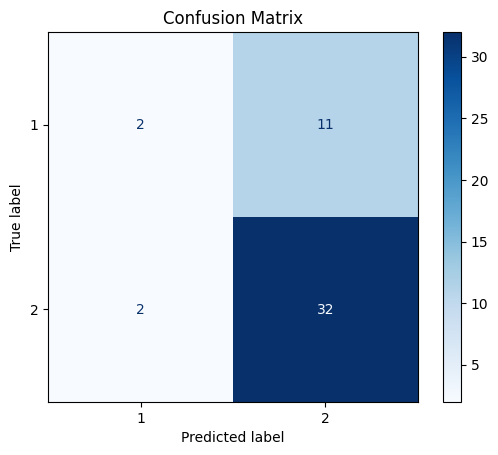

In [377]:
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

# 1. Get predictions
y_pred_b = model_logit.predict(x_test_b)

# 2. Create confusion matrix
cm = confusion_matrix(y_test_b, y_pred_b)

# 3. Plot it
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model_logit.classes_)
disp.plot(cmap='Blues')
plt.title("Confusion Matrix")
plt.show()


In [379]:
# Using Classification report
from sklearn.metrics import classification_report

In [381]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           1       0.50      0.15      0.24        13
           2       0.74      0.94      0.83        34

    accuracy                           0.72        47
   macro avg       0.62      0.55      0.53        47
weighted avg       0.68      0.72      0.67        47



In [ ]:
# Using another alternative -> Pandas_ml

In [383]:
class_names

['Die(1)', 'Live(2)']

In [387]:
print(classification_report(y_test, y_pred, target_names = class_names))

              precision    recall  f1-score   support

      Die(1)       0.50      0.15      0.24        13
     Live(2)       0.74      0.94      0.83        34

    accuracy                           0.72        47
   macro avg       0.62      0.55      0.53        47
weighted avg       0.68      0.72      0.67        47

